# PG-LIF — Phase P3b: Plateau-Gated e-prop on SHD (Regime B)
**Feeds:** manuscript Section 7.2 (Table 2) and the abstract's remaining Regime B placeholder.

**Design.** Online local learning with e-prop (symmetric feedback), forward-only — no BPTT graph. Neuron: the stable P1 configuration (κ = 0, β = 0), with the plateau state computed from the dendritic pathway and used **only** to gate plasticity. Three rules, identical in every other respect:
1. `eprop` — ungated baseline: Δw ∝ Σt L·e (eligibility traces × learning signal);
2. `plateau-gated` — Eq. (13): the update is multiplied by gᵢ[t] = min(1, pᵢ/pmax), **normalized by its batch mean** so the average update magnitude matches the ungated rule (otherwise the gate is confounded with a lower learning rate);
3. `permuted-gated` — the same normalized gate values permuted across neurons per step: the attribution control separating content-dependence from mere modulation.

**Hypothesis (pre-registered):** `plateau-gated` > `eprop` in accuracy or learning speed, and > `permuted-gated` if the advantage is content-dependent. (An earlier draft of this cell cited a 45.4% BPTT reference from the pre-v9 quick-mode consolidation run; that run has since been superseded by the verified 3-seed Regime A sweep, kappa=0 control 17.75 +/- 3.08%, and in any case used a different architecture/protocol than this online e-prop comparison, so no cross-regime accuracy reference is given here.)

**Runtime:** default `SEEDS = [0]`, 20 epochs per rule (~30–40 min on a T4; forward-only is faster per step than BPTT). Set `SEEDS = [0, 1, 2]` for the manuscript table (resumable; finished pairs are skipped). Results to `My Drive/PG_LIF/P3_results/gated_eprop_<stamp>/`.

In [1]:
import os, json, time, math
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = '/content/drive/My Drive'
    if not os.path.isdir(ROOT): ROOT = '/content/drive/MyDrive'
    BASE = os.path.join(ROOT, 'PG_LIF')
except Exception:
    BASE = './PG_LIF'
DATA = os.path.join(BASE, 'data', 'SHD')
P3_ROOT = os.path.join(BASE, 'P3_results')
OUT = os.path.join(P3_ROOT, 'gated_eprop_v2')   # v2: FIXED folder name (was a fresh timestamp every run,
    # which meant a new Colab session could never resume the previous session's finished seeds -- only
    # in-session re-runs of the training cell could skip already-done work). A fixed name lets every future
    # session find this same folder and its resume logic take over immediately.
os.makedirs(OUT, exist_ok=True)
T_BINS, MAX_TIME, N_IN, N_OUT, HIDDEN, BATCH, LR = 100, 1.4, 700, 20, 128, 64, 1e-3
EPOCHS = 20
SEEDS = [0, 1, 2, 3, 4]    # v2: widened from [0,1,2] to 5 seeds for higher statistical power
                            # (reviewer-requested). Seeds 0-2 are reused from the original timestamped run
                            # via the cross-folder scan below (see run_rule); only seeds 3-4 train fresh.
RULES = ['eprop', 'plateau-gated', 'permuted-gated']
print('Results folder:', OUT)

Mounted at /content/drive
Results folder: /content/drive/My Drive/PG_LIF/P3_results/gated_eprop_v2


In [2]:
import numpy as np, h5py, torch, torch.nn as nn
def load_split(fname):
    with h5py.File(os.path.join(DATA, fname), 'r') as f:
        return ([np.array(t) for t in f['spikes']['times']],
                [np.array(u) for u in f['spikes']['units']],
                np.array(f['labels'], dtype=np.int64))
TR = load_split('shd_train.h5'); TE = load_split('shd_test.h5')
def batches(split, batch_size, shuffle, device='cpu'):
    times, units, labels = split
    idx = np.random.permutation(len(labels)) if shuffle else np.arange(len(labels))
    for b0 in range(0, len(idx), batch_size):
        sel = idx[b0:b0+batch_size]
        x = torch.zeros(len(sel), T_BINS, N_IN)
        for i, j in enumerate(sel):
            tt = times[j]; uu = units[j]; keep = tt < MAX_TIME
            tb = np.clip((tt[keep] / MAX_TIME * T_BINS).astype(int), 0, T_BINS-1)
            x[i, tb, uu[keep]] = 1.0
        yield x.to(device), torch.as_tensor(labels[sel]).to(device)
print('train', len(TR[2]), '| test', len(TE[2]))

train 8156 | test 2264


## Forward-only PG-LIF network with e-prop traces
All quantities are maintained online: presynaptic traces (input and recurrent) filtered by the membrane decay, the somatic surrogate ψ, the plateau state p for the gate, and per-parameter pseudo-gradient accumulators. The learning signal is L = err · W_out (symmetric e-prop); the per-step error is softmax of the running readout minus the one-hot target. The readout trains on its own local gradient. Adam is applied to the accumulated pseudo-gradients, identically for all rules.

In [3]:
def decay(tau): return math.exp(-1.0 / tau)
AM, AD, AP, AO = decay(20), decay(20), decay(50), decay(20)
TH, TH_D, TREF_P, PMAX = 1.0, 1.0, 10, 2.0
PSI_SCALE = 0.3

class EpropNet:
    def __init__(self, seed, device):
        torch.manual_seed(seed)
        self.dev = device
        self.w_in = (torch.randn(HIDDEN, N_IN, device=device) / math.sqrt(N_IN)).requires_grad_(False)
        self.w_rec = torch.linalg.qr(torch.randn(HIDDEN, HIDDEN, device=device))[0]
        self.w_out = torch.zeros(N_OUT, HIDDEN, device=device)
        self.b_out = torch.zeros(N_OUT, device=device)
        self.params = {'w_in': self.w_in, 'w_rec': self.w_rec, 'w_out': self.w_out, 'b_out': self.b_out}
        self.adam_m = {k: torch.zeros_like(v) for k, v in self.params.items()}
        self.adam_v = {k: torch.zeros_like(v) for k, v in self.params.items()}
        self.adam_t = 0
    def forward_train(self, x, y, rule):
        B, T, _ = x.shape; dev = self.dev
        z = lambda *s: torch.zeros(*s, device=dev)
        vs, vd, p, rp = z(B, HIDDEN), z(B, HIDDEN), z(B, HIDDEN), z(B, HIDDEN)
        s = z(B, HIDDEN); vo = z(B, N_OUT); out_run = z(B, N_OUT)
        xtr_in = z(B, N_IN); xtr_rec = z(B, HIDDEN)          # presynaptic traces (alpha_m filtered)
        el_in = z(B, HIDDEN, N_IN); el_rec = z(B, HIDDEN, HIDDEN)   # readout-filtered eligibilities
        otr = z(B, HIDDEN)                                    # kappa-filtered spikes for readout grad
        g_in = z(HIDDEN, N_IN); g_rec = z(HIDDEN, HIDDEN); g_out = z(N_OUT, HIDDEN); g_b = z(N_OUT)
        y1 = torch.nn.functional.one_hot(y, N_OUT).float()
        nspk = 0.0
        for t in range(T):
            xt = x[:, t]
            iff = xt @ self.w_in.T; irec = s @ self.w_rec.T
            # dendrite -> plateau (gate only; kappa = 0)
            vd = AD * vd + iff
            ed = ((vd >= TH_D) & (rp == 0)).float()
            rp = torch.clamp(rp - 1, min=0) + ed * TREF_P
            p = AP * p + ed
            # soma (beta = 0)
            vs = AM * vs + iff + irec
            s_new = (vs >= TH).float()
            psi = PSI_SCALE * torch.clamp(1.0 - (vs - TH).abs(), min=0.0)
            vs = vs - s_new * TH
            nspk += s_new.sum().item()
            # presynaptic traces BEFORE update with current inputs
            xtr_in = AM * xtr_in + xt
            xtr_rec_prev = xtr_rec
            xtr_rec = AM * xtr_rec + s
            # eligibility: psi_i * xbar_j, filtered by readout decay
            el_in = AO * el_in + psi.unsqueeze(2) * xtr_in.unsqueeze(1)
            el_rec = AO * el_rec + psi.unsqueeze(2) * xtr_rec_prev.unsqueeze(1)
            s = s_new
            # readout
            otr = AO * otr + s
            vo = AO * vo + s @ self.w_out.T + self.b_out
            out_run = out_run + vo
            err = torch.softmax(out_run / (t + 1), dim=1) - y1        # (B, N_OUT)
            L = err @ self.w_out                                       # (B, HIDDEN) symmetric feedback
            # gate
            if rule == 'eprop':
                gate = torch.ones(B, HIDDEN, device=dev)
            else:
                graw = torch.clamp(p / PMAX, max=1.0)
                if rule == 'permuted-gated':
                    graw = graw[:, torch.randperm(HIDDEN, device=dev)]
                gate = graw / graw.mean().clamp(min=1e-4)              # unit-mean normalization
            LG = L * gate
            g_in += torch.einsum('bh,bhj->hj', LG, el_in) / B
            g_rec += torch.einsum('bh,bhj->hj', LG, el_rec) / B
            g_out += err.T @ otr / B
            g_b += err.mean(0)
        grads = {'w_in': g_in / T, 'w_rec': g_rec / T, 'w_out': g_out / T, 'b_out': g_b / T}
        self.adam_t += 1
        for k, gr in grads.items():
            gr = torch.clamp(gr, -1.0, 1.0)
            self.adam_m[k] = 0.9 * self.adam_m[k] + 0.1 * gr
            self.adam_v[k] = 0.999 * self.adam_v[k] + 0.001 * gr * gr
            mh = self.adam_m[k] / (1 - 0.9 ** self.adam_t)
            vh = self.adam_v[k] / (1 - 0.999 ** self.adam_t)
            self.params[k] -= LR * mh / (vh.sqrt() + 1e-8)
        return nspk / B
    def forward_eval(self, x):
        B, T, _ = x.shape; dev = self.dev
        z = lambda *sh: torch.zeros(*sh, device=dev)
        vs = z(B, HIDDEN); s = z(B, HIDDEN); vo = z(B, N_OUT); out = z(B, N_OUT)
        for t in range(T):
            iff = x[:, t] @ self.w_in.T; irec = s @ self.w_rec.T
            vs = AM * vs + iff + irec
            s = (vs >= TH).float(); vs = vs - s * TH
            vo = AO * vo + s @ self.w_out.T + self.b_out
            out = out + vo
        return out

def accuracy(net, split, device, limit=1024):
    correct = tot = 0
    for x, y in batches(split, 256, shuffle=False, device=device):
        out = net.forward_eval(x)
        correct += (out.argmax(1) == y).sum().item(); tot += len(y)
        if tot >= limit: break
    return correct / tot

## Training runs (resumable per rule and seed)

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu': print('WARNING: no GPU - slow.')
def run_rule(rule, seed):
    res_file = os.path.join(OUT, f'{rule}_s{seed}.json')
    if os.path.exists(res_file):
        print('[skip]', rule, seed, '(already finished in this folder)'); return json.load(open(res_file))

    # Cross-folder reuse: this exact (rule, seed) may already be finished in an OLDER timestamped folder
    # from before OUT had a fixed name (e.g. the original gated_eprop_<timestamp> run that produced the
    # manuscript's reported 3-seed numbers). Scan for it before training from scratch.
    fn = f'{rule}_s{seed}.json'
    for entry in sorted(os.listdir(P3_ROOT)) if os.path.isdir(P3_ROOT) else []:
        cand_dir = os.path.join(P3_ROOT, entry)
        if not os.path.isdir(cand_dir) or cand_dir == OUT:
            continue
        cand_file = os.path.join(cand_dir, fn)
        if os.path.exists(cand_file):
            cand = json.load(open(cand_file))
            if 'best_test' in cand and cand.get('history'):   # a genuinely finished run, not a partial file
                json.dump(cand, open(res_file, 'w'), indent=2)
                print(f'[reuse] {rule} seed {seed}: found finished result in {entry}, copied -- no retraining needed.')
                return cand

    np.random.seed(seed)
    net = EpropNet(seed, device)
    hist = []
    for ep in range(EPOCHS):
        t0 = time.time()
        for x, y in batches(TR, BATCH, shuffle=True, device=device):
            net.forward_train(x, y, rule)
        hist.append({'epoch': ep, 'train_acc': accuracy(net, TR, device),
                     'test_acc': accuracy(net, TE, device)})
        print(f"{rule:16s} s{seed} ep{ep:02d} train {hist[-1]['train_acc']:.3f} "
              f"test {hist[-1]['test_acc']:.3f} {time.time()-t0:.0f}s")
    res = {'rule': rule, 'seed': seed, 'history': hist,
           'best_test': max(h['test_acc'] for h in hist)}
    json.dump(res, open(res_file, 'w'), indent=2)
    return res

RES = [run_rule(r, sd) for r in RULES for sd in SEEDS]

[skip] eprop 0 (already finished in this folder)
[skip] eprop 1 (already finished in this folder)
[skip] eprop 2 (already finished in this folder)
[skip] eprop 3 (already finished in this folder)
[skip] eprop 4 (already finished in this folder)
[skip] plateau-gated 0 (already finished in this folder)
[skip] plateau-gated 1 (already finished in this folder)
[skip] plateau-gated 2 (already finished in this folder)
[skip] plateau-gated 3 (already finished in this folder)
[skip] plateau-gated 4 (already finished in this folder)
[skip] permuted-gated 0 (already finished in this folder)
[skip] permuted-gated 1 (already finished in this folder)
[skip] permuted-gated 2 (already finished in this folder)
[skip] permuted-gated 3 (already finished in this folder)
[skip] permuted-gated 4 (already finished in this folder)


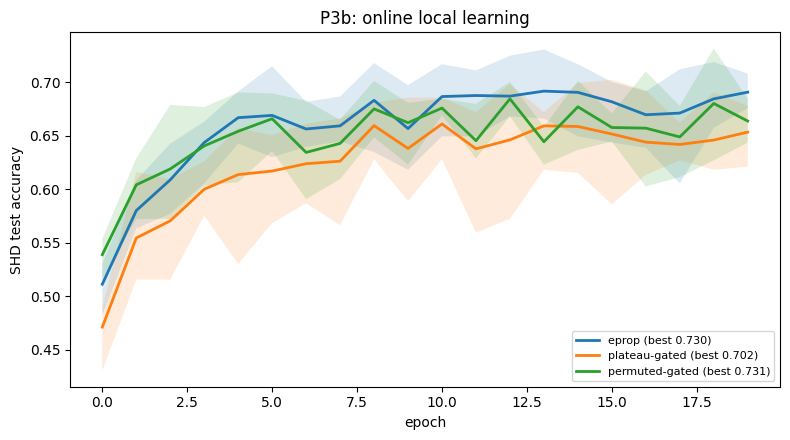


eprop            best test 0.719 ± 0.009
plateau-gated    best test 0.689 ± 0.013
permuted-gated   best test 0.706 ± 0.015

plateau-gated 0.689 ± 0.013 | eprop 0.719 ± 0.009 | permuted 0.706 ± 0.015  (n=5 seeds)
gate effect vs eprop: -3.0 pp | vs permuted: -1.7 pp
paired sign test plateau vs eprop (two-sided): p = 0.062
Reading: with 3 seeds, report mean ± std and the sign; the single-seed run already showed no positive gate effect.


In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4.5))
for r in RULES:
    hs = [x for x in RES if x['rule'] == r]
    # v2: guard against ragged histories -- if results were accumulated across sessions with different
    # EPOCHS settings (e.g. an older run reused via cross-folder resume had a different length than a
    # freshly-trained one), naively np.array()-ing a ragged list crashes. Truncate to the shortest common
    # length instead of failing, and warn so the mismatch is visible rather than silently misleading.
    lens = {len(x['history']) for x in hs}
    if len(lens) > 1:
        print(f'WARNING: {r} has mixed history lengths across seeds {sorted(lens)} -- '
              f'truncating all to {min(lens)} epochs for plotting. Reused results from an older '
              f'session likely used a different EPOCHS setting than this session.')
    n_ep = min(lens) if lens else EPOCHS
    curves = np.array([[h['test_acc'] for h in x['history'][:n_ep]] for x in hs])
    m = curves.mean(0)
    plt.plot(range(n_ep), m, lw=2, label=f"{r} (best {curves.max():.3f})")
    if curves.shape[0] > 1:
        plt.fill_between(range(n_ep), curves.min(0), curves.max(0), alpha=0.15)
# The reference line formerly here (0.454) was traced to the pre-v9, single-layer quick-mode consolidation
# run's kappa=0 control accuracy (45.4%), which the verified 3-seed Regime A sweep has since superseded
# (kappa=0 control: 17.75 +/- 3.08%, Table 1/3 of the manuscript) -- that earlier run also predates the v9
# gradient-finiteness-guard fix, so it is not a like-for-like comparison at any scale. Removed rather than
# re-plotted with the corrected number, since Regime A (BPTT, two-layer) and Regime B (e-prop, this notebook)
# are different architectures/protocols and a cross-regime accuracy reference line would itself be misleading
# regardless of which BPTT number it used.
plt.xlabel('epoch'); plt.ylabel('SHD test accuracy'); plt.legend(fontsize=8)
plt.title('P3b: online local learning')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'fig_p3b.png'), dpi=300); plt.show()
print()
for r in RULES:
    bt = [x['best_test'] for x in RES if x['rule'] == r]
    print(f'{r:16s} best test {np.mean(bt):.3f}' + (f' ± {np.std(bt):.3f}' if len(bt) > 1 else ''))
def by_seed(rule): return {x['seed']: x['best_test'] for x in RES if x['rule'] == rule}
bp, be, bm = by_seed('plateau-gated'), by_seed('eprop'), by_seed('permuted-gated')
common = sorted(set(bp) & set(be) & set(bm))
pg = np.mean([bp[s] for s in common]); ep_ = np.mean([be[s] for s in common]); pm = np.mean([bm[s] for s in common])
sd = lambda d: np.std([d[s] for s in common])
print(f'\nplateau-gated {pg:.3f} ± {sd(bp):.3f} | eprop {ep_:.3f} ± {sd(be):.3f} | permuted {pm:.3f} ± {sd(bm):.3f}  (n={len(common)} seeds)')
print(f'gate effect vs eprop: {100*(pg-ep_):+.1f} pp | vs permuted: {100*(pg-pm):+.1f} pp')
def sign_p(a, b):
    from math import comb
    d = [a[s]-b[s] for s in common]; n = sum(x!=0 for x in d)
    if n==0: return 1.0
    k = sum(x>0 for x in d)
    return min(1.0, 2*min(sum(comb(n,i) for i in range(k,n+1)), sum(comb(n,i) for i in range(0,k+1)))/2**n)
if len(common) >= 3:
    print(f'paired sign test plateau vs eprop (two-sided): p = {sign_p(bp,be):.3f}')
print('Reading: with 3 seeds, report mean ± std and the sign; the single-seed run already showed no positive gate effect.')

### Notes
- e-prop is expected to land below the BPTT reference (45.4%); the claim under test is the *relative* effect of the gate, not absolute accuracy.
- The unit-mean gate normalization is essential to the comparison's fairness and is stated in the manuscript.
- If the gate shows no effect (or hurts), that is reported; combined with the positive P3a result, the honest conclusion would be that the gate helps one-shot imprinting but not gradual online discrimination — a scientifically coherent boundary worth stating.